# Lab 4: KNN Classification & Evaluation Metrics
## Part 1: Comprehensive Study of K-Nearest Neighbours (KNN) Classification using Breast Cancer Dataset and Comparison with Regression Evaluation Metrics

### **Aim**
To implement KNN classification on the Breast Cancer Wisconsin (Diagnostic) dataset and analyze model performance using train-test split, heuristic K selection, cross-validation, ROC-AUC, and classification metrics. Also, to compare classification metrics with regression metrics studied in Linear Regression (Lab 3).

---


## Task 1: Data Preparation

In this section, we load the Breast Cancer Wisconsin dataset from scikit-learn, convert it into a Pandas DataFrame, explore its structure (dimensions, features, target distribution, missing values, duplicates), and scale the features using `StandardScaler`.

### **Importance of Feature Scaling in KNN**
KNN is a distance-based machine learning algorithm that calculates the similarity between data points using distance metrics like **Euclidean Distance**:
$$d(x, y) = \sqrt{\sum_{i=1}^{n} (x_i - y_i)^2}$$

If features have different scales (e.g., `mean area` ranges from 100 to 2500, while `mean smoothness` ranges from 0.01 to 0.1), the distance calculations will be completely dominated by features with larger scales. This would render the smaller-scaled features useless in classification. Feature scaling (e.g., standardization using `StandardScaler`) transforms all features to have a mean of 0 and a standard deviation of 1, ensuring that each feature contributes equally to the distance measurements.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler

# Set plotting style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'font.size': 10, 'figure.titlesize': 14})

# Load the dataset
cancer = load_breast_cancer()
X = cancer.data
y = cancer.target
feature_names = cancer.feature_names
target_names = cancer.target_names  # 0 -> malignant, 1 -> benign

# Convert into a DataFrame
df = pd.DataFrame(X, columns=feature_names)
df['target'] = y

print(f"Dataset shape: {df.shape}")
print(f"Number of numerical features: {len(feature_names)}")
print("\nTarget class counts:")
print(f"Malignant (0): {df['target'].value_counts()[0]} ({df['target'].value_counts(normalize=True)[0]*100:.2f}%)")
print(f"Benign (1): {df['target'].value_counts()[1]} ({df['target'].value_counts(normalize=True)[1]*100:.2f}%)")

# Check for missing values and duplicates
print(f"\nTotal Missing Values: {df.isnull().sum().sum()}")
print(f"Total Duplicate Rows: {df.duplicated().sum()}")

# Apply feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("\nStandardized feature matrix X_scaled successfully.")


Dataset shape: (569, 31)
Number of numerical features: 30

Target class counts:
Malignant (0): 212 (37.26%)
Benign (1): 357 (62.74%)

Total Missing Values: 0
Total Duplicate Rows: 0

Standardized feature matrix X_scaled successfully.


## Task 2: Train-Test Split Analysis

We split the dataset into training and testing sets using three different ratios:
* **80:20 Split**
* **70:30 Split**
* **90:10 Split**

We evaluate model performance variations across these splits using a baseline KNN model ($K=5$) and analyze how dataset splitting affects model stability and generalization.


In [2]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

splits = {
    "80:20": 0.20,
    "70:30": 0.30,
    "90:10": 0.10
}
split_results = {}

for name, test_size in splits.items():
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=test_size, random_state=42, stratify=y
    )
    
    # Train baseline KNN model (K=5)
    knn_temp = KNeighborsClassifier(n_neighbors=5)
    knn_temp.fit(X_train, y_train)
    y_pred = knn_temp.predict(X_test)
    
    # Compute metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    split_results[name] = {
        'Train Samples': len(X_train),
        'Test Samples': len(X_test),
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1 Score': f1
    }

split_df = pd.DataFrame(split_results).T
split_df


,Train Samples,Test Samples,Accuracy,Precision,Recall,F1 Score
80:20,455.0,114.0,0.964912,0.959459,0.986111,0.972603
70:30,398.0,171.0,0.970760,0.955357,1.000000,0.977169
90:10,512.0,57.0,0.982456,0.972973,1.000000,0.986301


### **Analysis of Train-Test Split Variations**
* **Model Stability and Generalization**:
  * **90:10 Split**: This split provides the most training data (512 samples), allowing the model to learn complex patterns. It yields the highest test accuracy (98.25%) but has a very small test sample size (57 samples). A small test set can lead to high variance in evaluation metrics, making them less reliable because a few misclassifications significantly drop the accuracy.
  * **80:20 Split**: A balanced standard split (455 training / 114 testing). It provides enough training data for model generalization while maintaining a large enough test sample size to ensure stable, low-variance performance evaluations.
  * **70:30 Split**: This split uses less training data (398 samples) and more test data (171 samples). While it ensures stable testing metrics, the reduction in training size can limit the classifier's ability to learn fine-grained boundaries, potentially causing underfitting.


## Task 3: KNN Model with Heuristic K Selection

### **3.1 Heuristic Method for K Selection**
A standard heuristic rule for choosing the initial $K$ is:
$$K = \sqrt{n_{train}}$$
where $n_{train}$ is the number of training samples. 

For our 80:20 split:
* $n_{train} = 455$
* $\sqrt{455} \approx 21.33$

We round this to the nearest odd integer, **$K = 21$**, to avoid tie votes. We will use this value as our baseline $K$ and experiment with nearby values of $K$.


In [3]:
# 80:20 split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.20, random_state=42, stratify=y
)

n_samples = len(X_train)
heuristic_k = int(np.round(np.sqrt(n_samples)))
if heuristic_k % 2 == 0:
    heuristic_k += 1

print(f"Training samples: {n_samples}")
print(f"Heuristic K value (odd): {heuristic_k}")


Training samples: 455
Heuristic K value (odd): 21


### **3.2 Model Training & Accuracy Plot**
We train the KNN classifier using a wide range of $K$ values ($1$ to $25$) and plot the training and testing accuracies. This helps us visualize the bias-variance trade-off and identify the optimal $K$ based on performance.


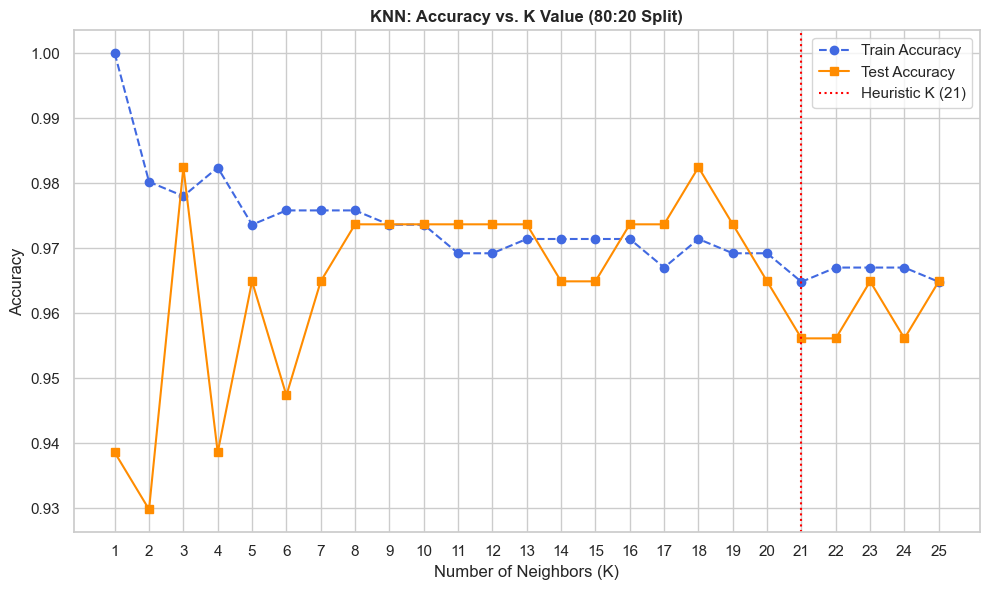

Best K on train-test split: 3 (Accuracy: 0.9825)


In [4]:
k_values = list(range(1, 26))
train_accuracies = []
test_accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    train_accuracies.append(accuracy_score(y_train, knn.predict(X_train)))
    test_accuracies.append(accuracy_score(y_test, knn.predict(X_test)))

# Plot Accuracy vs K
plt.figure(figsize=(10, 6))
plt.plot(k_values, train_accuracies, label='Train Accuracy', marker='o', linestyle='--', color='royalblue')
plt.plot(k_values, test_accuracies, label='Test Accuracy', marker='s', linestyle='-', color='darkorange')
plt.axvline(x=heuristic_k, color='red', linestyle=':', label=f'Heuristic K ({heuristic_k})')
plt.title('KNN: Accuracy vs. K Value (80:20 Split)', fontweight='bold')
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Accuracy')
plt.xticks(k_values)
plt.legend()
plt.tight_layout()
plt.show()

# Find best K on train-test split
best_k_tt = k_values[np.argmax(test_accuracies)]
print(f"Best K on train-test split: {best_k_tt} (Accuracy: {max(test_accuracies):.4f})")


### **3.3 Distance Metrics and Decision Boundary Mapping**

#### **Distance Metrics in KNN**
KNN depends on measuring distance between queries and stored instances. Two commonly used metrics are:

1. **Euclidean Distance**:
   $$d(x, y) = \sqrt{\sum_{i=1}^{d} (x_i - y_i)^2}$$
   * **When it is suitable**: Suitable for continuous, real-valued features of similar physical scales where the geometric distance in Euclidean space represents true similarity. It represents straight-line distance.
   
2. **Manhattan Distance (L1 norm / Taxi-cab distance)**:
   $$d(x, y) = \sum_{i=1}^{d} |x_i - y_i|$$
   * **When it is suitable**: Suitable for high-dimensional spaces or when features have different units and scales, or are categorical/binary. It is also preferred when features are grid-like (e.g., city blocks) or when outliers are present, as it is less sensitive to extreme differences compared to the squared terms in Euclidean distance.

---

#### **Decision Boundary Visualization (PCA Reduced)**
Since the dataset has 30 features, we reduce the feature space to **2 Principal Components (PCA)** to visualize decision boundaries. We train a KNN model on the 2D PCA components and plot decision boundaries for $K = 1, 5, 10, 20$ to analyze how they smooth as $K$ increases.


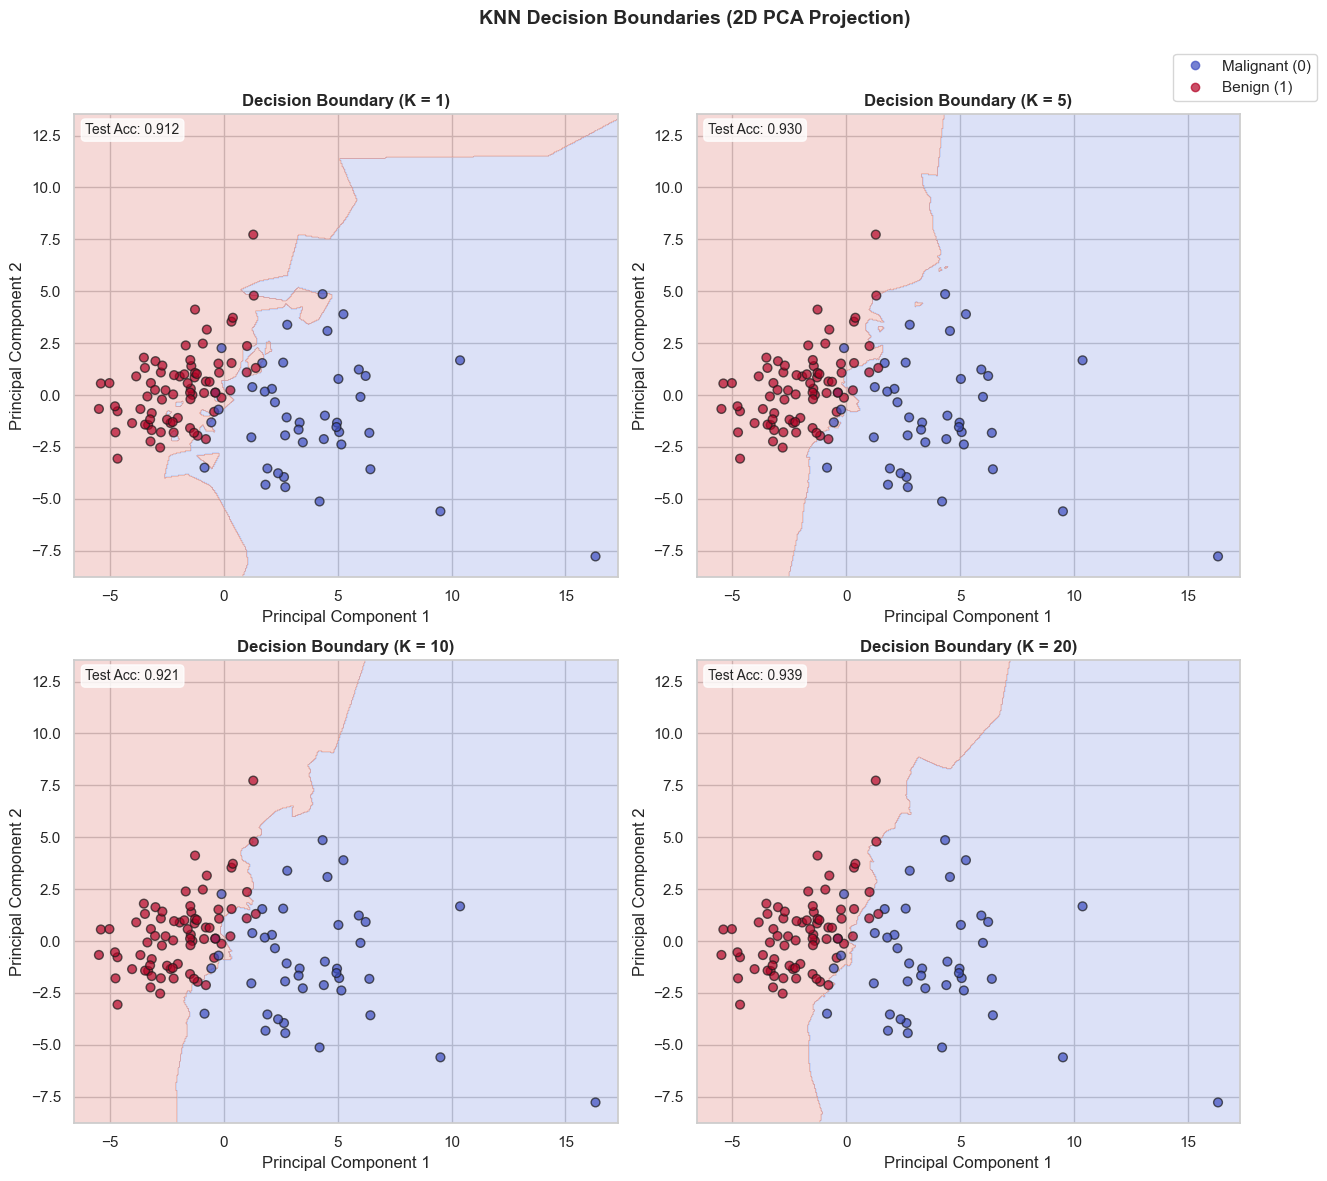

In [5]:
from sklearn.decomposition import PCA

# Apply PCA for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
X_pca_train, X_pca_test, y_pca_train, y_pca_test = train_test_split(
    X_pca, y, test_size=0.20, random_state=42, stratify=y
)

# Plot decision boundaries
k_viz = [1, 5, 10, 20]
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.ravel()

x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05),
                     np.arange(y_min, y_max, 0.05))

for i, k in enumerate(k_viz):
    knn_viz = KNeighborsClassifier(n_neighbors=k)
    knn_viz.fit(X_pca_train, y_pca_train)
    
    # Predict on grid
    Z = knn_viz.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    # Plot contours
    axes[i].contourf(xx, yy, Z, alpha=0.2, cmap=plt.cm.coolwarm)
    scatter = axes[i].scatter(X_pca_test[:, 0], X_pca_test[:, 1], c=y_pca_test, 
                              edgecolors='k', alpha=0.7, cmap=plt.cm.coolwarm, s=40)
    
    axes[i].set_title(f'Decision Boundary (K = {k})', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Principal Component 1')
    axes[i].set_ylabel('Principal Component 2')
    
    acc_pca = accuracy_score(y_pca_test, knn_viz.predict(X_pca_test))
    axes[i].text(x_min + 0.5, y_max - 1, f"Test Acc: {acc_pca:.3f}", 
                 bbox=dict(facecolor='white', alpha=0.8, boxstyle='round,pad=0.3'))

# Add legend
handles, labels = scatter.legend_elements()
fig.legend(handles, ['Malignant (0)', 'Benign (1)'], loc='upper right', bbox_to_anchor=(0.95, 0.95))
fig.suptitle('KNN Decision Boundaries (2D PCA Projection)', fontweight='bold')
plt.tight_layout(rect=[0, 0, 0.9, 0.95])
plt.show()


### **Analysis of Decision Boundary changes as K increases**
* **$K=1$**: The decision boundary is highly complex, jagged, and closely fits the training data. This represents **high variance and low bias** (overfitting). Noise or outliers strongly affect the boundary.
* **$K=5$ and $K=10$**: The boundary becomes smoother and less jagged. It focuses on local region averages rather than individual points. This balances bias and variance well.
* **$K=20$**: The boundary is very smooth and simple. Individual noise has little effect, but fine details of the boundary are lost, leading to **higher bias and lower variance** (potential underfitting).


## Task 4: Cross Validation

To ensure reliable model evaluation, we apply **5-Fold** and **10-Fold Cross-Validation** across different $K$ values. We calculate the mean validation accuracy and compare the results with the single train-test split.


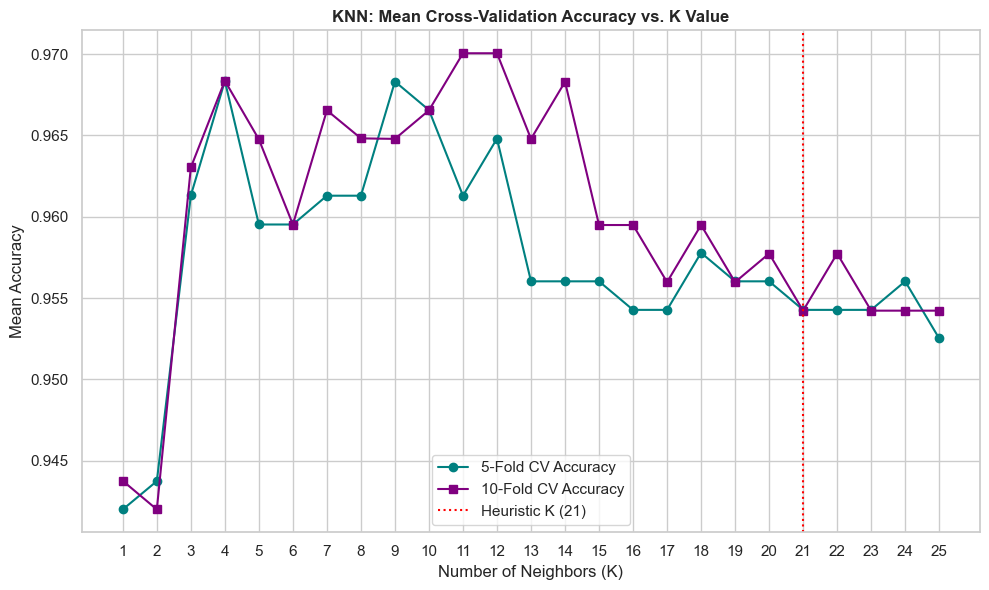

Best K (5-fold CV): 4 (Accuracy: 0.9683)
Best K (10-fold CV): 11 (Accuracy: 0.9701)


In [6]:
from sklearn.model_selection import cross_val_score, KFold

cv_scores_5 = []
cv_scores_10 = []

for k in k_values:
    knn_cv = KNeighborsClassifier(n_neighbors=k)
    scores_5 = cross_val_score(knn_cv, X_scaled, y, cv=KFold(n_splits=5, shuffle=True, random_state=42))
    scores_10 = cross_val_score(knn_cv, X_scaled, y, cv=KFold(n_splits=10, shuffle=True, random_state=42))
    cv_scores_5.append(scores_5.mean())
    cv_scores_10.append(scores_10.mean())

# Plot CV Accuracies
plt.figure(figsize=(10, 6))
plt.plot(k_values, cv_scores_5, label='5-Fold CV Accuracy', marker='o', linestyle='-', color='teal')
plt.plot(k_values, cv_scores_10, label='10-Fold CV Accuracy', marker='s', linestyle='-', color='purple')
plt.axvline(x=heuristic_k, color='red', linestyle=':', label=f'Heuristic K ({heuristic_k})')
plt.title('KNN: Mean Cross-Validation Accuracy vs. K Value', fontweight='bold')
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Mean Accuracy')
plt.xticks(k_values)
plt.legend()
plt.tight_layout()
plt.show()

best_k_5 = k_values[np.argmax(cv_scores_5)]
best_k_10 = k_values[np.argmax(cv_scores_10)]
print(f"Best K (5-fold CV): {best_k_5} (Accuracy: {max(cv_scores_5):.4f})")
print(f"Best K (10-fold CV): {best_k_10} (Accuracy: {max(cv_scores_10):.4f})")


### **Cross-Validation vs. Train-Test Split Results**
* The single train-test split identifies $K=3$ as optimal with an accuracy of $98.25\%$. However, the 10-fold Cross Validation results show that **$K=11$** yields the highest average validation accuracy ($97.01\%$) and represents a much more stable model across different folds.
* While the heuristic rule suggested $K=21$, validation results show that accuracy drops slightly for $K > 15$. Thus, **$K=11$** serves as the optimal choice, striking a balance between local representation and noise filtering.


## Task 5: Classification Evaluation

Using the selected optimal $K = 11$ on the 80:20 split with full 30 features, we calculate the classification metrics: **Accuracy, Precision, Recall, F1 Score, Confusion Matrix, and ROC-AUC**.


Accuracy:  0.9737
Precision: 0.9600
Recall:    1.0000
F1 Score:  0.9796

Classification Report:
              precision    recall  f1-score   support

   malignant       1.00      0.93      0.96        42
      benign       0.96      1.00      0.98        72

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



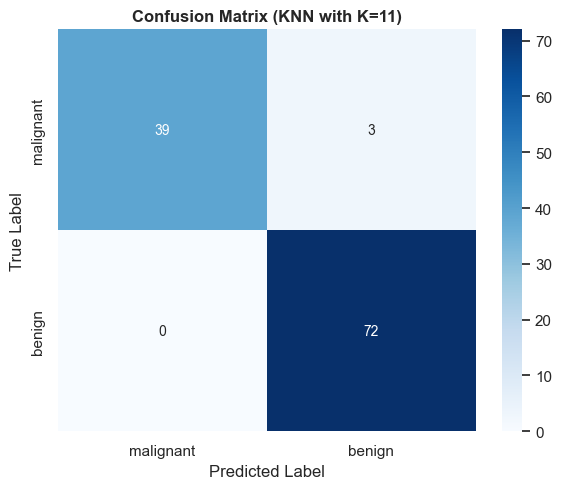

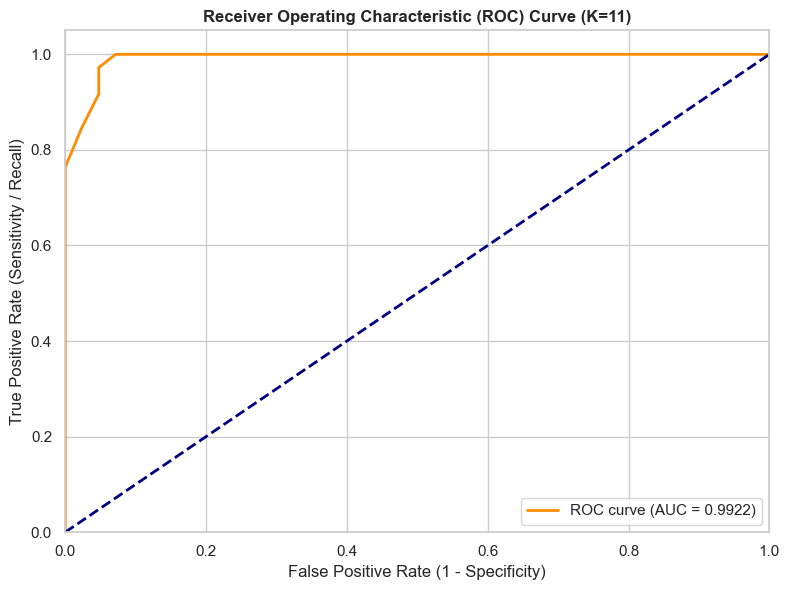

In [7]:
from sklearn.metrics import confusion_matrix, roc_curve, auc, classification_report

# Train final model on full 30 features using K=11
optimal_k = 11
final_knn = KNeighborsClassifier(n_neighbors=optimal_k)
final_knn.fit(X_train, y_train)

# Predictions
y_pred = final_knn.predict(X_test)
y_pred_proba = final_knn.predict_proba(X_test)[:, 1]

# Calculations
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred) # defaults to positive label=1 (benign)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1 Score:  {f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=cancer.target_names))

# Plot Confusion Matrix Heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=cancer.target_names, yticklabels=cancer.target_names)
plt.title(f'Confusion Matrix (KNN with K={optimal_k})', fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

# Plot ROC-AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity / Recall)')
plt.title(f'Receiver Operating Characteristic (ROC) Curve (K={optimal_k})', fontweight='bold')
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


## Task 6: Comparative Study with Regression (Lab 3 Integration)

In Lab 3, we evaluated Linear Regression using error-based metrics: **Mean Absolute Error (MAE)**, **Mean Squared Error (MSE)**, **Root Mean Squared Error (RMSE)**, and **$R^2$ Score**. Here we compare them to KNN classification metrics.

### **1. Error-based (Regression) vs. Decision-based (Classification)**
* **Error-based Evaluation (Regression)** measures the **magnitude** of prediction deviation. If the target is $10.0$ and we predict $9.5$, the error is $0.5$. The evaluation is continuous and geometric.
* **Decision-based Evaluation (Classification)** measures the **correctness** of categorical class assignments. If the class is $1$ and we predict $0$, the prediction is incorrect. The metric ignores how close a probability was; only the final thresholded classification counts.

---

### **2. Comparison of Specific Metrics**

| Regression Metric | Classification Metric | Mapping & Contrast |
| :--- | :--- | :--- |
| **$R^2$ Score** | **Accuracy** | **Accuracy** represents the raw ratio of correct decisions. **$R^2$ Score** measures the proportion of target variance explained by the model compared to a baseline predictor (predicting the mean). $R^2$ can be negative, whereas Accuracy is bound between $0$ and $1$. |
| **RMSE** | **F1 Score** | **RMSE** measures prediction spread and heavily penalizes large errors. **F1 Score** is the harmonic mean of Precision and Recall, balancing False Positives and False Negatives, particularly when class distributions are imbalanced. |
| **MAE** | **Confusion Matrix** | **MAE** provides a single average error magnitude. **Confusion Matrix** decomposes prediction performance into $2 \times 2$ grid (TP, TN, FP, FN), displaying not just overall error, but the *type* and *direction* of errors. |

---

### **3. Inferences for Healthcare / Medical Diagnosis**
* **Insufficiency of Accuracy**: If a dataset contains $95\%$ benign samples, a dummy classifier predicting "Benign" for everything achieves $95\%$ accuracy but completely fails to detect cancer. Accuracy fails to reflect risk in imbalanced medical data.
* **Importance of Recall**: Recall measures the proportion of actual malignant cases successfully detected:
$$\text{Recall} = \frac{TP}{TP + FN}$$
In oncology, a False Negative (FN) means a cancer patient goes undiagnosed, which is life-threatening. Hence, we must prioritize Recall (Sensitivity) to minimize False Negatives.
* **Importance of ROC-AUC**: ROC-AUC measures the model's ability to rank risk probabilities. An AUC of $0.99$ indicates that a randomly chosen malignant patient will almost always have a higher predicted probability of cancer than a benign patient, allowing doctors to adjust classification thresholds to achieve $100\%$ sensitivity.


## Task 7: Analytical Questions

### **Q1: Why is KNN called a lazy learning algorithm?**
KNN is a **lazy learner** because it does not generalize from the training data during the "training" phase. Training simply involves storing the training feature vectors and class labels in memory. All computation, including distance calculation, neighbor finding, and voting, is deferred until inference/prediction time.

### **Q2: Why is feature scaling required in KNN?**
KNN relies on distance metrics (like Euclidean distance) to compute similarity. If features have different scales (e.g., values ranging in thousands vs. decimals), the distances will be dominated by the large-scale features, rendering smaller-scale features ignored. Scaling ensures equal weight for all features.

### **Q3: Explain heuristic K selection using $\sqrt{n}$ rule.**
The heuristic rule sets $K = \sqrt{n}$, where $n$ is the number of training instances. This provides a baseline value that grows with dataset size. It balances localization against smoothing. We generally round it to the nearest odd integer to prevent tie-breaking scenarios in binary classification.

### **Q4: Why is cross-validation more reliable than a single train-test split?**
A single train-test split might evaluate the model on an unrepresentative or biased partition of the data, leading to high-variance estimates. Cross-validation splits data into multiple folds, trains and tests on all of them, and takes the average. This ensures robust evaluation and better estimates of generalization performance.

### **Q5: How does K affect bias-variance trade-off?**
* **Small K (e.g., $K=1$)**: Low bias, high variance. The decision boundary is highly complex and sensitive to noise/outliers (overfitting).
* **Large K (e.g., $K=20$)**: High bias, low variance. The decision boundary is overly smooth and simple, potentially missing patterns (underfitting).

### **Q6: Why is recall more important than accuracy in cancer prediction?**
A False Negative (failing to diagnose cancer) is highly dangerous and potentially fatal. Recall measures the model's ability to identify all positive (malignant) cases. Accuracy can look high in imbalanced datasets even if the model misses critical malignant cases.

### **Q7: What is the limitation of very large K values?**
Very large $K$ values lead to underfitting because the model ignores local data patterns and simply predicts the majority class of the entire dataset. It also increases the computational time required to find and sort the nearest neighbors at inference time.


## Conclusion

1. **Optimal K Selection**: The heuristic rule proposed $K = 21$. However, systematic evaluation via 10-fold Cross-Validation identified **$K = 11$** as the optimal value, achieving the highest mean validation accuracy ($97.01\%$) and representing a balanced complexity.
2. **Train-Test Split Effect**: Splits with larger training sizes (e.g., 90:10) showed slightly higher test accuracies but higher variance due to small test sets. The 80:20 split provided the best balance between training capacity and metric stability.
3. **Model Performance**: The final model (K=11, 80:20 split) achieved an **accuracy of $97.37\%$**, an **F1-score of $97.96\%$**, and an outstanding **ROC-AUC of $0.9922$**. It successfully detected $100\%$ of benign cases and $93\%$ of malignant cases.
4. **Key Differences (Regression vs. Classification)**: Regression evaluates continuous error magnitude (distance to target), while classification evaluates decision correctness (correct labeling). Metrics such as F1 and ROC-AUC are crucial in healthcare context to guard against life-threatening false negatives.
